# Hybrid control

#### 1. Initialize & check scene

In [1]:
import os
import sys
import numpy as np
import time
import mujoco
sys.path.append(os.path.abspath('../'))
from pp_base_mujoco.VIEWER import *
from pp_base_mujoco.UTILS import *
from pp_base_mujoco.SPEC_HELPER import *
from pp_base_mujoco.KINEMATICS import *

In [2]:
spec_helper = MjSpecHelper()
spec_helper.add_robot(
    path='../asset/panda/panda_ee_sphere.xml',
    body_name="base",
    p=(0, 0.7, 0),
    r=(0, 0, -1.57),
    # r=(0, 0, 0),
    prefix="",
    suffix="_right"
)
spec_helper.add_robot(
    path='../asset/panda/panda_ee_sphere.xml',
    body_name="base",
    p=(0, -0.7, 0),
    r=(0, 0, 1.57),
    # r=(0, 0, 0),
    prefix="",
    suffix="_left"
)
spec_helper.add_geom(
    name="box",
    type='box',
    size=(0.15, 0.15, 0.15),
    freejoint = True,
    p=(0.2, 0, 0.15),
    r=(0, 0, 0),
    rgba=(0.3, 0.3, 0.3, 0.5),
    group=1,
    # friction=(1.0, 0.005, 0.0001),
    friction=(0.3, 0.01, 0.001),
    mass=0.05
)
# spec_helper.add_body(
#     name="box",
#     freejoint = False,
#     p=(0.2, 0, 0.15),
#     r=(0, 0, 0),
# )
spec_helper.add_site(
    name="contact_right",
    size=(0.05,0.05,0.05),
    p=(0, 0.15+0.05, 0),
    r=(0, 0, 0),
    rgba=(0.3, 0.3, 1.0, 1.0),
    group=2,
    body_name="box"
)
spec_helper.add_site(
    name="contact_left",
    size=(0.05,0.05,0.05),
    p=(0, -0.15-0.05, 0),
    r=(0, 0, 0),
    rgba=(0.3, 0.3, 1.0, 1.0),
    group=2,
    body_name="box"
)
spec_helper.add_site(
    name="center",
    size=(0.05,0.05,0.05),
    p=(0, 0, 0),
    r=(0, 0, 0),
    rgba=(0.3, 0.3, 1.0, 1.0),
    group=2,
    body_name="box"
)

model, data = spec_helper.compile()
spec_helper.save_to_xml("../asset/xml/scene_panda_lr.xml")
model.opt.timestep = 0.001
dt = model.opt.timestep

In [3]:
# q_traj_left = np.load("./traj/q_left_trajectory.npy")
# q_traj_right = np.load("./traj/q_right_trajectory.npy")
q_traj_left = np.load("./traj/q_left_traj_100.npy")
q_traj_right = np.load("./traj/q_right_traj_100.npy")
print(f"q_traj_left shape: {q_traj_left.shape}, q_traj_right shape: {q_traj_right.shape}")

q_traj_left shape: (100, 7), q_traj_right shape: (100, 7)


In [4]:
joint_names = get_joint_names(model, data)
joint_names_left = [name for name in joint_names if name is not None and "_left" in name]
joint_names_right = [name for name in joint_names if name is not None and "_right" in name]
actuator_names = get_actuator_names(model, data)
actuator_names_left = [name for name in actuator_names if name is not None and "_left" in name]
actuator_names_right = [name for name in actuator_names if name is not None and "_right" in name]

""" GO TO INITIAL QPOS """
qpos_init = np.array([0, -0.5, 0, -2.5, 0, 2.0, 0.5]) # set initial qpos
apply_qpos_names(model, data, names=joint_names_left, value=qpos_init)
apply_qpos_names(model, data, names=joint_names_right, value=qpos_init)
mujoco.mj_forward(model, data)

""" VIEW """
viewer = MUJOCOGLVIEWER(model, data)
viewer.view_geom(group=0, show=False)
viewer.view_geom(group=1, show=True)
mujoco.mj_resetData(model, data)
apply_qpos_names(model, data, names=joint_names_left, value=q_traj_left[0])
apply_qpos_names(model, data, names=joint_names_right, value=q_traj_right[0])
mujoco.mj_forward(model, data)

while viewer.is_alive():
    mujoco.mj_kinematics(model, data)
    viewer.render()

viewer.close()
del(viewer)

In [5]:
def get_body_contact_force_position(
        model,
        data,
        body1_name,
        body2_name,
        ):
    body1_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, body1_name)
    body2_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, body2_name)
    contact_forces = []
    contact_positions = []
    for i in range(data.ncon):
        contact = data.contact[i]
        body1_in_contact_id = model.geom_bodyid[contact.geom1]
        body2_in_contact_id = model.geom_bodyid[contact.geom2]
        if (body1_in_contact_id == body1_id and body2_in_contact_id == body2_id) or (body1_in_contact_id == body2_id and body2_in_contact_id == body1_id):
            force = np.zeros(6) # (6,)
            mujoco.mj_contactForce(model,data,i,force)
            contact_forces.append(force)
            contact_positions.append(contact.pos)
    return contact_forces, contact_positions

In [6]:
""" PARAMETER - for 100 waypoints"""
# PID controller gain
Kp_q = 70.0 #* 0.1
Ki_q = 0.02 #* 0.05
Kd_q = 7.0 #* 0.3
# PI controller gain
Kp_force = 0.3 #* 0.1 # 0.3
Ki_force = 0.005 #* 0.05
force_magnitude = 4.0 #* 0.1 # 5 newtons 
Kp_ee = 0.0 # 10.0
Kd_ee = 0.0 # 1.0

In [7]:
# """ PARAMETER - for 20 waypoints"""
# # PID controller gain
# Kp_q = 20.0 #* 0.1
# Ki_q = 0.002 #* 0.05
# Kd_q = 20.0 #* 0.3
# # PI controller gain
# Kp_force = 0.08 #* 0.1 # 0.3
# Ki_force = 0.001 #* 0.05
# force_magnitude = 4.0 #* 0.1 # 5 newtons 
# Kp_ee = 0.0 # 10.0
# Kd_ee = 0.0 # 1.0

In [8]:
cartesian_force_list = []

viewer = MUJOCOGLVIEWER(model, data)
viewer.view_geom(group=0, show=False)
viewer.view_geom(group=1, show=True)
viewer.options[0].flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = True
mujoco.mj_resetData(model, data)
apply_qpos_names(model, data, names=joint_names_left, value=q_traj_left[0])
apply_qpos_names(model, data, names=joint_names_right, value=q_traj_right[0])
mujoco.mj_forward(model, data)

joint_dofadr_left = [model.jnt_dofadr[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, name)] for name in joint_names_left]
joint_dofadr_right = [model.jnt_dofadr[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, name)] for name in joint_names_right]

# initialize push force 
f_push_left = np.zeros(3)
f_push_right = np.zeros(3)
# force error accumulation for integral term
f_accumulated_left = np.zeros(3)
f_accumulated_right = np.zeros(3)
# initialize goal q 
idx = 0
q_goal_left = q_traj_left[idx]
q_goal_right = q_traj_right[idx]
# initialize error sum for integral term
error_sum_left = np.zeros_like(q_goal_left)
error_sum_right = np.zeros_like(q_goal_right)

running_flag = True
while viewer.is_alive():
    if glfw.get_key(viewer.windows[0], glfw.KEY_SPACE) == glfw.PRESS:
        if clicked_once == False:
            running_flag = not running_flag
            clicked_once = True
    else: clicked_once = False
    if glfw.get_key(viewer.windows[0], glfw.KEY_R) == glfw.PRESS:
        mujoco.mj_resetData(model, data)
        apply_qpos_names(model, data, names=joint_names_left, value=q_traj_left[0])
        apply_qpos_names(model, data, names=joint_names_right, value=q_traj_right[0])
        mujoco.mj_forward(model, data)
        idx = 0
        q_goal_left = q_traj_left[idx]
        q_goal_right = q_traj_right[idx]
        error_sum_left[:] = 0.0
        error_sum_right[:] = 0.0
        f_accumulated_left[:] = 0.0
        f_accumulated_right[:] = 0.0
    """ CALCULATE OPTIMIZATION TORQUE """
    q_current_left = get_qpos_with_names(model, data, names=joint_names_left)
    q_current_right = get_qpos_with_names(model, data, names=joint_names_right)
    qvel_left = get_qvel_with_names(model, data, names=joint_names_left)
    qvel_right = get_qvel_with_names(model, data, names=joint_names_right)
    q_diff_left = q_goal_left - q_current_left
    q_diff_right = q_goal_right - q_current_right
    # get pid controller goal 
    pos_ok = (
        np.max(np.abs(q_diff_left)) < 0.01 and
        np.max(np.abs(q_diff_right)) < 0.01
    )
    vel_ok = (
        np.max(np.abs(qvel_left)) < 0.05 and
        np.max(np.abs(qvel_right)) < 0.05
    )
    if pos_ok and vel_ok:
        if idx < len(q_traj_left) - 1:
            if running_flag == True:
                idx += 1
            q_goal_left = q_traj_left[idx]
            q_goal_right = q_traj_right[idx]
            error_sum_left[:] = 0.0
            error_sum_right[:] = 0.0
            print(f"current index: {idx}")
    # get accumulated error for integral term
    error_sum_left += q_diff_left * dt
    error_sum_right += q_diff_right * dt
    error_sum_left = np.clip(error_sum_left, -1.0, 1.0)
    error_sum_right = np.clip(error_sum_right, -1.0, 1.0)
    control_signal_left = Kp_q * q_diff_left + Ki_q * error_sum_left - Kd_q * qvel_left
    control_signal_right = Kp_q * q_diff_right + Ki_q * error_sum_right - Kd_q * qvel_right
    control_signal_left= control_signal_left * 5.0
    control_signal_right = control_signal_right * 5.0
    print(f"q following torque norm: {np.linalg.norm(control_signal_left):.2f}, {np.linalg.norm(control_signal_right):.2f}")

    """ CALCULATE PUSH TORQUE """
    # get jacobian 
    jac_p_right, jac_R_right = get_jacobian(model, data, 'eef_sphere_right', type='geom', joints_use=joint_names_right)
    jac_p_left, jac_R_left = get_jacobian(model, data, 'eef_sphere_left', type='geom', joints_use=joint_names_left)
    jac_left = np.concatenate([jac_p_left, jac_R_left], axis=0)
    jac_right = np.concatenate([jac_p_right, jac_R_right], axis=0)
    # get push force torque 
    # p_center = get_p(model, data, name="center", type='site')
    # p_target_contact_left = get_p(model, data, name="contact_left", type='site')
    # p_target_contact_right = get_p(model, data, name="contact_right", type='site')
    # direction_push_left = (p_center - p_target_contact_left) / np.linalg.norm(p_center - p_target_contact_left)
    # direction_push_right = (p_center - p_target_contact_right) / np.linalg.norm(p_center - p_target_contact_right)
    f_push_target_left = force_magnitude * np.array([0, 1, 0]) 
    f_push_target_right = force_magnitude * np.array([0, -1, 0])
    # gravity compensation for object 
    box_mass = model.body_mass[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "box")]
    gravity = model.opt.gravity
    f_gravity_compensation = np.array([0, 0, box_mass * gravity[2]])
    f_push_target_left += f_gravity_compensation
    f_push_target_right += f_gravity_compensation
    f_push_left, p_contact_left = get_body_contact_force_position(model, data, body1_name="right_hand_left", body2_name="box")
    f_push_right, p_contact_right = get_body_contact_force_position(model, data, body1_name="right_hand_right", body2_name="box")
    if len(f_push_left) == 0:
        f_push_left = np.zeros(3)
    else:
        f_push_left = f_push_left[0][:3] # take the first contact and only force part
    if len(f_push_right) == 0:
        f_push_right = np.zeros(3)
    else:
        f_push_right = f_push_right[0][:3] # take the first contact and only force part
    f_push_error_left = f_push_target_left - f_push_left
    f_push_error_right = f_push_target_right - f_push_right
    f_accumulated_left += f_push_error_left * 0.01 # integral term with dt=0.01s
    f_accumulated_right += f_push_error_right * 0.01
    f_push_desired_left = f_push_target_left + Kp_force * f_push_error_left + Ki_force * f_accumulated_left
    f_push_desired_right = f_push_target_right + Kp_force * f_push_error_right + Ki_force * f_accumulated_right
    torque_push_left = jac_p_left.T @ f_push_desired_left # * 2.0
    torque_push_right = jac_p_right.T @ f_push_desired_right # * 2.0
    print(f"push torque norm: {np.linalg.norm(torque_push_left):.2f}, {np.linalg.norm(torque_push_right):.2f}")

    """ CALCULATE EE POSITION CONTROL TORQUE """
    p_ee_target_left = get_p(model, data, name="contact_left", type='site')
    p_ee_target_right = get_p(model, data, name="contact_right", type='site')
    p_ee_left = get_p(model, data, name="eef_sphere_left", type='geom')
    p_ee_right = get_p(model, data, name="eef_sphere_right", type='geom')
    p_ee_left_error = p_ee_target_left - p_ee_left
    p_ee_right_error = p_ee_target_right - p_ee_right
    v_ee_target_left = np.zeros(3)
    v_ee_target_right = np.zeros(3)
    qvel_left = get_qvel_with_names(model, data, names=joint_names_left)
    qvel_right = get_qvel_with_names(model, data, names=joint_names_right)
    v_ee_left = jac_p_left @ qvel_left
    v_ee_right = jac_p_right @ qvel_right
    v_ee_left_error = v_ee_target_left - v_ee_left
    v_ee_right_error = v_ee_target_right - v_ee_right
    f_ee_desired_left = Kp_ee * p_ee_left_error + Kd_ee * v_ee_left_error
    f_ee_desired_right = Kp_ee * p_ee_right_error + Kd_ee * v_ee_right_error
    torque_ee_left = jac_p_left.T @ f_ee_desired_left
    torque_ee_right = jac_p_right.T @ f_ee_desired_right
    print(f"ee control torque norm: {np.linalg.norm(torque_ee_left):.2f}, {np.linalg.norm(torque_ee_right):.2f}")

    # bias force
    q_frc_bias_left = data.qfrc_bias[joint_dofadr_left]
    q_frc_bias_right = data.qfrc_bias[joint_dofadr_right]
    # combine control signal and push torque, and apply torque limits
    total_torque_left = q_frc_bias_left + control_signal_left + torque_push_left + torque_ee_left
    total_torque_right = q_frc_bias_right + control_signal_right + torque_push_right + torque_ee_right
    # total_torque_left = q_frc_bias_left + control_signal_left + torque_push_left
    # total_torque_right = q_frc_bias_right + control_signal_right + torque_push_right
    # total_torque_left = q_frc_bias_left + torque_push_left
    # total_torque_right = q_frc_bias_right + torque_push_right

    apply_ctrl_names(model, data, names=actuator_names_left, value=total_torque_left)
    apply_ctrl_names(model, data, names=actuator_names_right, value=total_torque_right)

    mujoco.mj_step(model, data)
    viewer.render()
    # cartesian_force_list.append((np.linalg.norm(f_push_left), np.linalg.norm(f_push_right)))
    cartesian_force_list.append((abs(f_push_left[1]), abs(f_push_right[1])))

viewer.close()
del viewer

current index: 1
q following torque norm: 0.00, 0.00
push torque norm: 2.59, 2.59
ee control torque norm: 0.00, 0.00
q following torque norm: 11.76, 11.75
push torque norm: 2.59, 2.59
ee control torque norm: 0.00, 0.00
q following torque norm: 10.84, 10.83
push torque norm: 2.59, 2.59
ee control torque norm: 0.00, 0.00
q following torque norm: 10.06, 10.05
push torque norm: 2.59, 2.59
ee control torque norm: 0.00, 0.00
q following torque norm: 9.38, 9.37
push torque norm: 2.59, 2.59
ee control torque norm: 0.00, 0.00
q following torque norm: 8.78, 8.77
push torque norm: 2.59, 2.59
ee control torque norm: 0.00, 0.00
q following torque norm: 8.25, 8.24
push torque norm: 2.59, 2.59
ee control torque norm: 0.00, 0.00
q following torque norm: 7.77, 7.76
push torque norm: 2.59, 2.59
ee control torque norm: 0.00, 0.00
q following torque norm: 7.34, 7.33
push torque norm: 2.59, 2.59
ee control torque norm: 0.00, 0.00
q following torque norm: 6.95, 6.95
push torque norm: 2.59, 2.59
ee control t

2026-04-10 13:54:00.679 python[12615:468538] TSM AdjustCapsLockLEDForKeyTransitionHandling - _ISSetPhysicalKeyboardCapsLockLED Inhibit


q following torque norm: 2.36, 2.41
push torque norm: 3.28, 3.35
ee control torque norm: 0.00, 0.00
q following torque norm: 2.36, 2.41
push torque norm: 3.29, 3.35
ee control torque norm: 0.00, 0.00
q following torque norm: 2.36, 2.41
push torque norm: 3.29, 3.36
ee control torque norm: 0.00, 0.00
q following torque norm: 2.35, 2.40
push torque norm: 3.29, 3.36
ee control torque norm: 0.00, 0.00
q following torque norm: 2.35, 2.40
push torque norm: 3.29, 3.36
ee control torque norm: 0.00, 0.00
q following torque norm: 2.35, 2.40
push torque norm: 3.29, 3.36
ee control torque norm: 0.00, 0.00
q following torque norm: 2.34, 2.40
push torque norm: 3.29, 3.36
ee control torque norm: 0.00, 0.00
q following torque norm: 2.34, 2.39
push torque norm: 3.29, 3.36
ee control torque norm: 0.00, 0.00
q following torque norm: 2.34, 2.39
push torque norm: 3.30, 3.36
ee control torque norm: 0.00, 0.00
q following torque norm: 2.33, 2.39
push torque norm: 3.30, 3.36
ee control torque norm: 0.00, 0.00


cartesian_force_list length: 2


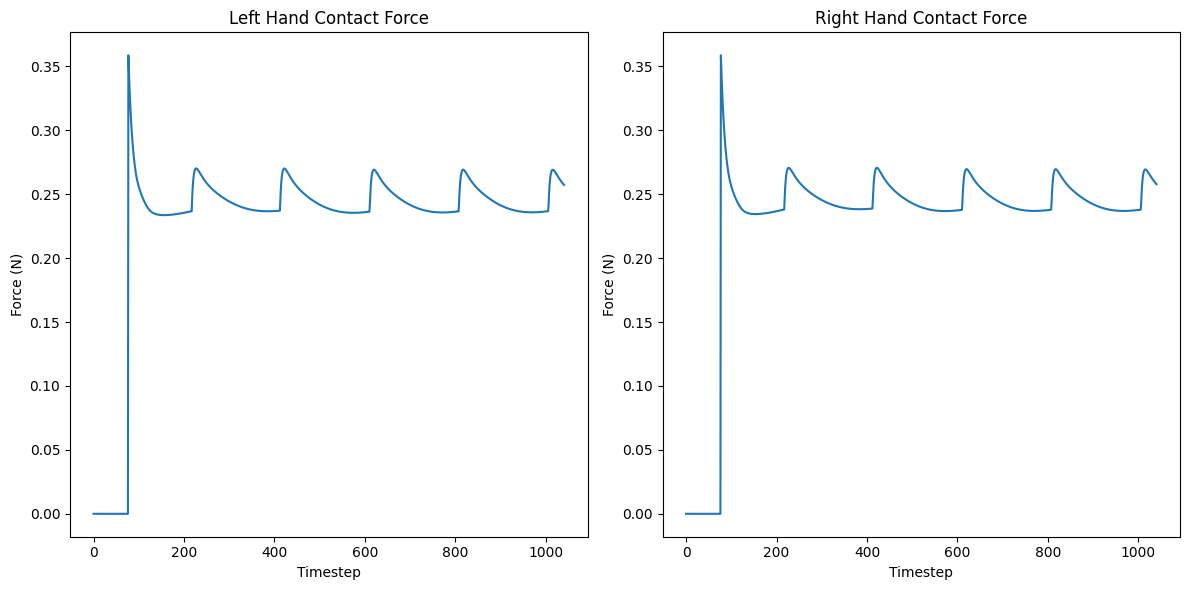

In [9]:
# shape of cartesian_force_list 
print(f"cartesian_force_list length: {len(cartesian_force_list[0])}")

# plot cartesian forces
import matplotlib.pyplot as plt
forces_left = np.array([f[0] for f in cartesian_force_list])
forces_right = np.array([f[1] for f in cartesian_force_list])
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(forces_left)
plt.title("Left Hand Contact Force")
plt.xlabel("Timestep")
plt.ylabel("Force (N)")
plt.subplot(1, 2, 2)
plt.plot(forces_right)
plt.title("Right Hand Contact Force")
plt.xlabel("Timestep")
plt.ylabel("Force (N)")
plt.tight_layout()
plt.show()